# Predictive Maintenance — EDA & Feature Engineering (EDA & Feature Engineering)
### Project: Industrial Predictive Maintenance & Failure Prevention
### Dataset: AI4I 2020 Predictive Maintenance Dataset (UCI), `ai4i2020.csv`
**This notebook provides:**
- Loading correct data
- Modeling on multiple models
- Class-Weighting
- Threshold optimiztaion
- Hyperparameter Tuning on best model so far
- Saving all your work for next tasks

## Load & Prepare the Data Split from `features.py`

In [7]:
import sys
sys.path.append("..")
from src.features import build_pipeline_splits

splits = build_pipeline_splits("../data/ai4i2020_raw.csv")

# Note: each of these is a TUPLE (X, y), not separate keys
X_train, y_train = splits['train']
X_val, y_val = splits['val']
X_test, y_test = splits['test']

feature_names = splits['feature_names']
preprocessor = splits['preprocessor']   # fitted ColumnTransformer, keep this if you need to transform new data later
zscorer = splits['zscorer']             # fitted TypeGroupedZScorer, same reason

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Failure rate (train):", y_train.mean())
print("\nFeatures:")
for f in feature_names:
    print(" -", f)

Train shape: (7000, 14) (7000,)
Val shape: (1500, 14) (1500,)
Test shape: (1500, 14) (1500,)
Failure rate (train): 0.033857142857142856

Features:
 - num__Air temperature [K]
 - num__Process temperature [K]
 - num__Rotational speed [rpm]
 - num__Torque [Nm]
 - num__Tool wear [min]
 - num__temp_diff_K
 - num__power_W
 - num__torque_x_toolwear
 - num__speed_torque_ratio
 - num__air_temp_z_within_type
 - cat_onehot__Type_H
 - cat_onehot__Type_L
 - cat_onehot__Type_M
 - cat_ordinal__tool_wear_bucket


## Logistic Regression Baseline
We start with a plain Logistic Regression (no class weighting, default
0.5 threshold) to establish a reference point before addressing class
imbalance. Given the severe imbalance (3.39% positive), we expect this
baseline to have low recall — it will likely miss many real failures,
since the default threshold and unweighted loss are biased toward the
majority class. This is intentional: it's the "before" picture that
motivates class-weighting and threshold tuning later.

Primary metrics: PR-AUC, recall, precision, F1, false-negative rate.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, average_precision_score, confusion_matrix,
    recall_score, precision_score, f1_score, precision_recall_curve
)

- AS we stated before, we shall not rely on `accuracy_score` in this highly imbalanced dataset so we will not use it at all

In [9]:
from src.model_utils import (
    train_and_evaluate, plot_confusion_matrix, plot_pr_curve,
    plot_feature_importance, predict_new_sample
)

In [10]:
r_logreg = train_and_evaluate(LogisticRegression(max_iter=1000, random_state=42),
                                X_train, y_train, X_val, y_val, "Logistic Regression — baseline")

=== Logistic Regression — baseline (threshold=0.5) ===
model: Logistic Regression — baseline
threshold: 0.5
precision: 0.55
recall: 0.21568627450980393
f1: 0.30985915492957744
pr_auc: 0.39642786497022536
false_negative_rate: 0.7843137254901961
tn: 1440
fp: 9
fn: 40
tp: 11

Full report:
               precision    recall  f1-score   support

           0      0.973     0.994     0.983      1449
           1      0.550     0.216     0.310        51

    accuracy                          0.967      1500
   macro avg      0.761     0.605     0.647      1500
weighted avg      0.959     0.967     0.960      1500



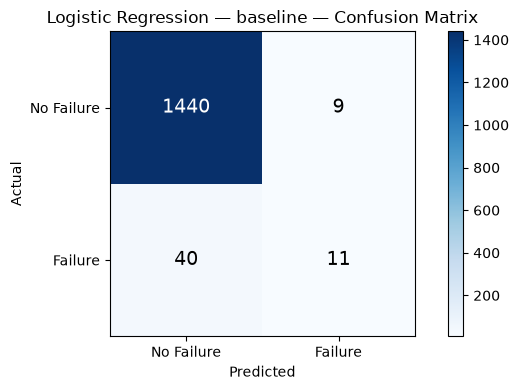

In [11]:
plot_confusion_matrix(r_logreg)

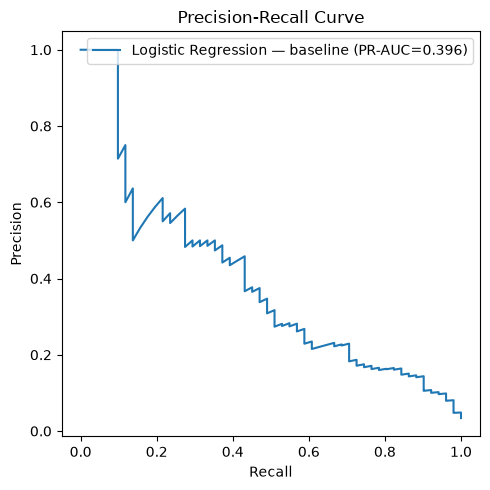

<Axes: title={'center': 'Precision-Recall Curve'}, xlabel='Recall', ylabel='Precision'>

In [12]:
plot_pr_curve(r_logreg)

**Observations Logistic Regression — Baseline**
- Recall is very low (21.6%), meaning the model misses **40 of 51** real
failures on the validation set [As it appears in CM]. This confirms the expected weakness: a
**linear** decision boundary struggles with this dataset's non-linear
sensor interactions (e.g. torque × tool wear), and the unweighted loss
is dominated by the 96.6% majority class. 
- PR-AUC of 0.396 is by far the
lowest of all models tested — Logistic Regression is not a viable
candidate here without substantial rework (e.g. weighting, polynomial
features), and is kept only as the required baseline reference point.
- This confirms the need for class-weighting and threshold tuning, addressed in the next sections.

## Decision Tree
Next, a Decision Tree classifier. Trees can capture non-linear
interactions between sensor variables (e.g. torque × tool wear) without
manual feature crosses, and are naturally interpretable via their
structure and feature importances. We again start unweighted for a fair
comparison against the Logistic Regression baseline, then note where
class imbalance affects results similarly.

We cap `max_depth` to avoid a tree that trivially memorizes the 237
positive training examples (severe overfitting risk given how few
positives exist).

In [14]:
from sklearn.tree import DecisionTreeClassifier
r_dtree = train_and_evaluate(DecisionTreeClassifier(max_depth=5, random_state=42),
                               X_train, y_train, X_val, y_val, "Decision Tree (max_depth=5)")

=== Decision Tree (max_depth=5) (threshold=0.5) ===
model: Decision Tree (max_depth=5)
threshold: 0.5
precision: 0.9130434782608695
recall: 0.8235294117647058
f1: 0.865979381443299
pr_auc: 0.8322012014261413
false_negative_rate: 0.17647058823529413
tn: 1445
fp: 4
fn: 9
tp: 42

Full report:
               precision    recall  f1-score   support

           0      0.994     0.997     0.996      1449
           1      0.913     0.824     0.866        51

    accuracy                          0.991      1500
   macro avg      0.953     0.910     0.931      1500
weighted avg      0.991     0.991     0.991      1500



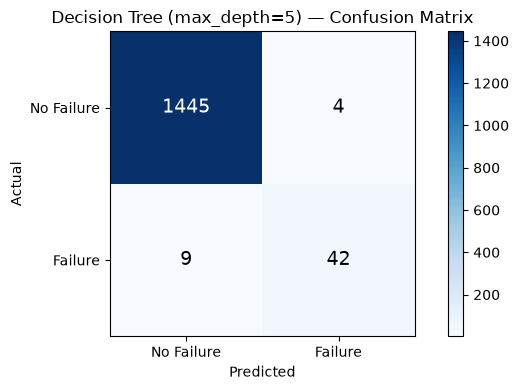

In [15]:
plot_confusion_matrix(r_dtree)

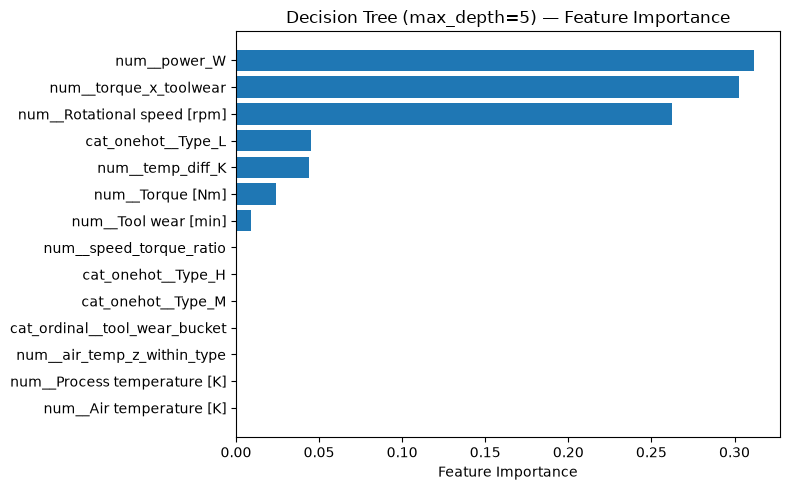

In [16]:
plot_feature_importance(r_dtree,feature_names)

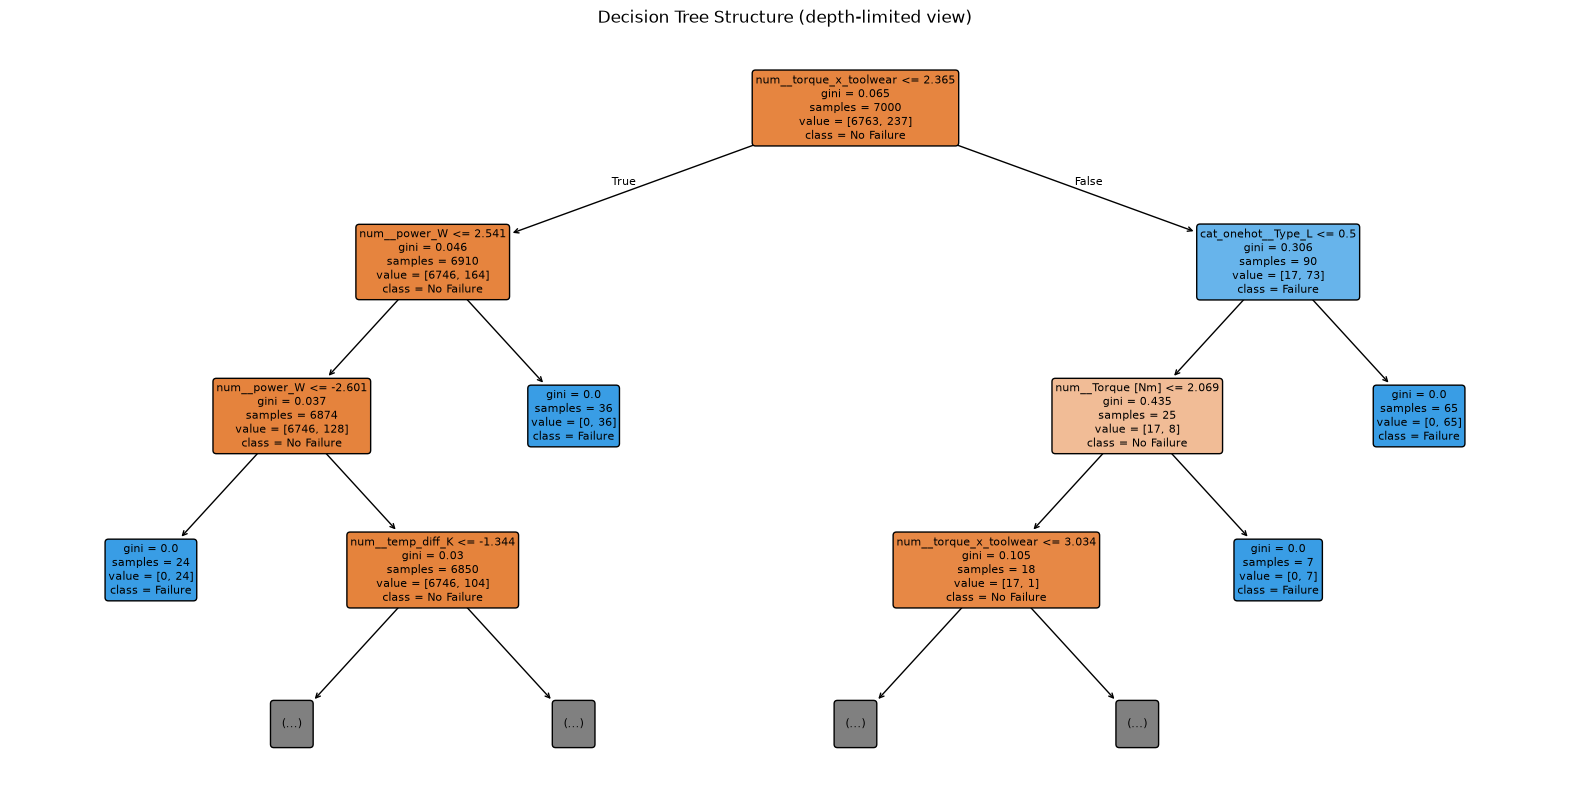

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# for the plot
dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree.fit(X_train,y_train)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dtree, feature_names=feature_names, class_names=["No Failure", "Failure"],
    filled=True, rounded=True, max_depth=3, fontsize=8, ax=ax
)
plt.title("Decision Tree Structure (depth-limited view)")
plt.show()

**Observations of Decision Tree (max_depth=5)**
A single tree already outperforms Logistic Regression by a wide margin:
recall of 82.4% (9 missed failures vs. 40) and precision of 91.3%.
PR-AUC (0.832) confirms this isn't just a lucky threshold — the model
ranks positive cases well overall. This suggests the failure signal in
this dataset is genuinely non-linear, which linear models cannot
capture but simple trees already exploit effectively.

## Random Forest
Random Forest averages many decision trees to reduce the overfitting risk
seen with a single tree, while still handling non-linear feature
interactions well. We again start unweighted, matching Logistic
Regression and the Decision Tree, to keep this comparison fair before
we introduce class weighting as a separate, explicit experiment.

In [25]:
from sklearn.ensemble import RandomForestClassifier
r_rf = train_and_evaluate(RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
                            X_train, y_train, X_val, y_val, "Random Forest")

=== Random Forest (threshold=0.5) ===
model: Random Forest
threshold: 0.5
precision: 0.975
recall: 0.7647058823529411
f1: 0.8571428571428571
pr_auc: 0.9046442284661483
false_negative_rate: 0.23529411764705882
tn: 1448
fp: 1
fn: 12
tp: 39

Full report:
               precision    recall  f1-score   support

           0      0.992     0.999     0.996      1449
           1      0.975     0.765     0.857        51

    accuracy                          0.991      1500
   macro avg      0.983     0.882     0.926      1500
weighted avg      0.991     0.991     0.991      1500



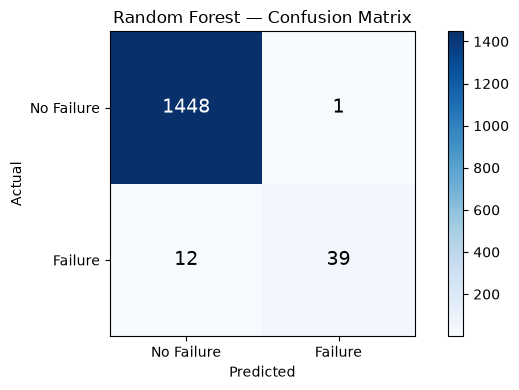

In [26]:
plot_confusion_matrix(r_rf)

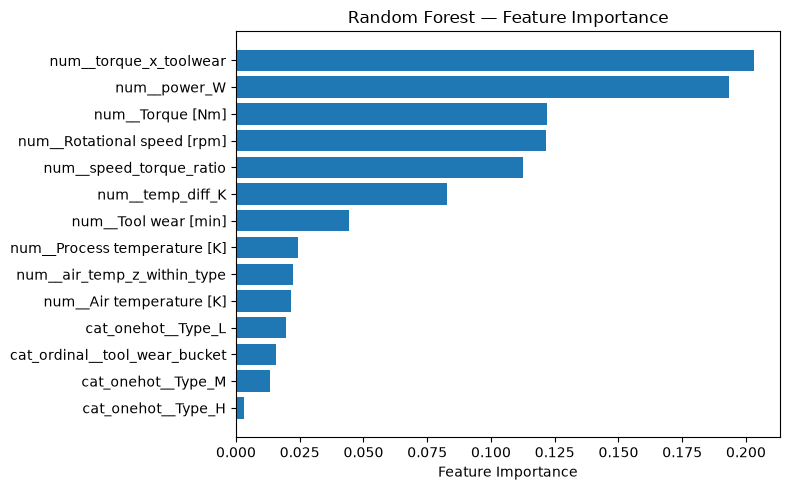

In [27]:
plot_feature_importance(r_rf,feature_names)

**Observations of Random Forest**
Random Forest achieves the **best PR-AUC of all models (0.905)** and the
highest precision (97.5%, only 1 false alarm), while maintaining strong
recall (76.5%). It misses 12 failures — more than the Decision Tree in
absolute terms, but ranks candidate failures more reliably overall
(higher PR-AUC), making it a strong candidate once we apply threshold
tuning to push recall higher without sacrificing much precision.

## Gradient Boosting (XGBoost)

XGBoost builds trees sequentially, each correcting the previous ones'
errors, typically giving stronger performance than a single Random
Forest on structured/tabular data. We first train it unweighted for a
fair baseline comparison, then reuse it as the primary model for the
class-weighting and threshold-optimization experiments below, since it
is expected to be our strongest candidate.

In [28]:
from xgboost import XGBClassifier
r_xgb = train_and_evaluate(XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                                            random_state=42, eval_metric="logloss"),
                             X_train, y_train, X_val, y_val, "XGBoost")

=== XGBoost (threshold=0.5) ===
model: XGBoost
threshold: 0.5
precision: 0.8541666666666666
recall: 0.803921568627451
f1: 0.8282828282828283
pr_auc: 0.8517698809266505
false_negative_rate: 0.19607843137254902
tn: 1442
fp: 7
fn: 10
tp: 41

Full report:
               precision    recall  f1-score   support

           0      0.993     0.995     0.994      1449
           1      0.854     0.804     0.828        51

    accuracy                          0.989      1500
   macro avg      0.924     0.900     0.911      1500
weighted avg      0.988     0.989     0.989      1500



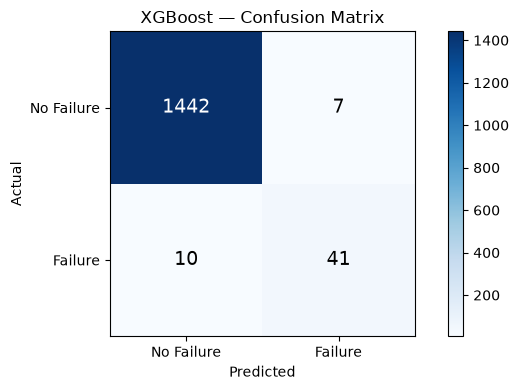

In [29]:
plot_confusion_matrix(r_xgb)

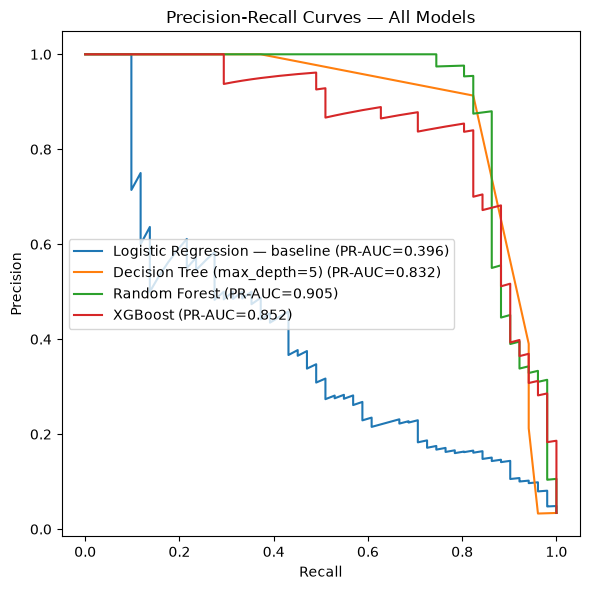

In [30]:
fig, ax = plt.subplots(figsize=(6, 6))
for r in [r_logreg, r_dtree, r_rf, r_xgb]:
    plot_pr_curve(r, ax=ax, show=False)
plt.title("Precision-Recall Curves — All Models")
plt.tight_layout()
plt.show()

**Observations of XGBoost (unweighted)**
XGBoost matches Random Forest's recall (80.4% vs. 76.5%, actually
slightly higher) but with notably lower precision (85.4% vs. 97.5%) and
a lower PR-AUC (0.852 vs. 0.905). At the default threshold, Random
Forest currently ranks ahead of unweighted XGBoost on our priority
metric (PR-AUC), though this may change once XGBoost is tuned in the
next section.

## Class-Weighting Experiment

Given the 3.39% failure rate, all models above were trained without
addressing the imbalance directly. Here we retrain our strongest
candidate (XGBoost) with class weighting, to see whether it materially
improves recall — the metric we care about most, since missed failures
are costlier than false alarms per the project's business framing.

For XGBoost, class weighting is applied via `scale_pos_weight`, set to
the ratio of negative to positive training examples, instead of SMOTE

In [31]:
rf_weighted = RandomForestClassifier(
    n_estimators=300, max_depth=8, random_state=42,
    class_weight="balanced", n_jobs=-1
)
rf_weighted.fit(X_train, y_train)

r_rf_weighted = train_and_evaluate(
    rf_weighted, X_train, y_train, X_val, y_val,
    "Random Forest (class-weighted)", already_fitted=True
)

=== Random Forest (class-weighted) (threshold=0.5) ===
model: Random Forest (class-weighted)
threshold: 0.5
precision: 0.5454545454545454
recall: 0.8235294117647058
f1: 0.65625
pr_auc: 0.7874846270792064
false_negative_rate: 0.17647058823529413
tn: 1414
fp: 35
fn: 9
tp: 42

Full report:
               precision    recall  f1-score   support

           0      0.994     0.976     0.985      1449
           1      0.545     0.824     0.656        51

    accuracy                          0.971      1500
   macro avg      0.770     0.900     0.820      1500
weighted avg      0.978     0.971     0.974      1500



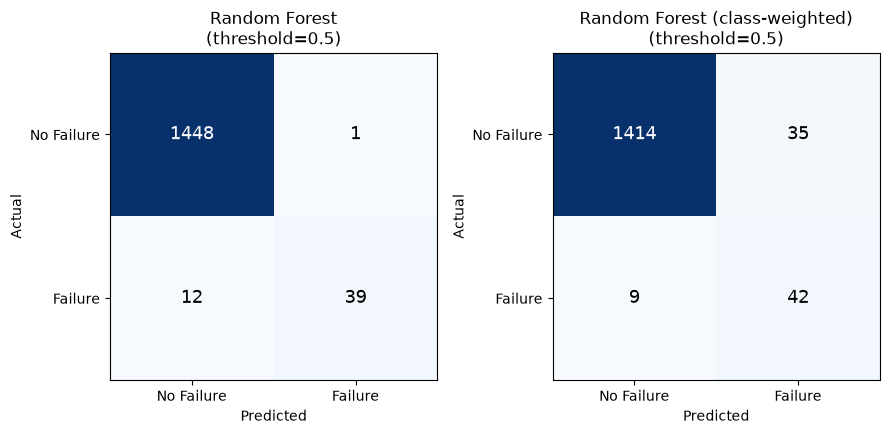

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

for ax, r in zip(axes, [r_rf, r_rf_weighted]):
    cm = confusion_matrix(r["y_val"], r["y_pred"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No Failure", "Failure"])
    ax.set_yticklabels(["No Failure", "Failure"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"{r['model']}\n(threshold={r['threshold']})")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)

plt.tight_layout()
plt.show()

**Observations of Random Forest — Class-Weighting Experiment**

Class weighting (`class_weight="balanced"`) changes Random Forest's
behavior substantially at the default threshold. Recall improves from
76.5% (unweighted) to 82.4% (weighted) — 3 fewer missed failures (12 →
9) — but precision drops sharply, from 97.5% to 54.5%, and PR-AUC falls
from 0.905 to 0.787.

## Threshold Optimization

Rather than relying on the default 0.5 decision threshold, we search for
a threshold that better reflects the business priority: minimizing false
negatives (missed failures) is more important than minimizing false
positives (unnecessary maintenance checks). We sweep thresholds and
select one that maximizes recall subject to a minimum acceptable
precision, using the class-weighted Random Forest

In [33]:
import numpy as np
precisions, recalls, thresholds = precision_recall_curve(y_val, r_rf_weighted["y_proba"])

min_precision = 0.30
valid_idx = np.where(precisions[:-1] >= min_precision)[0]
best_idx = valid_idx[np.argmax(recalls[:-1][valid_idx])]
best_threshold = thresholds[best_idx]

print(f"Selected threshold: {best_threshold:.3f}")

Selected threshold: 0.224


In [34]:
r_rf_tuned = train_and_evaluate(
    r_rf_weighted["fitted_model"],       # reuse the already-fitted model, don't refit
    X_train, y_train, X_val, y_val,
    f"Random Forest (weighted)",
    threshold=best_threshold,
    already_fitted=True
)

=== Random Forest (weighted) (threshold=0.2236993750403414) ===
model: Random Forest (weighted)
threshold: 0.2236993750403414
precision: 0.30120481927710846
recall: 0.9803921568627451
f1: 0.4608294930875576
pr_auc: 0.7874846270792064
false_negative_rate: 0.0196078431372549
tn: 1333
fp: 116
fn: 1
tp: 50

Full report:
               precision    recall  f1-score   support

           0      0.999     0.920     0.958      1449
           1      0.301     0.980     0.461        51

    accuracy                          0.922      1500
   macro avg      0.650     0.950     0.709      1500
weighted avg      0.976     0.922     0.941      1500



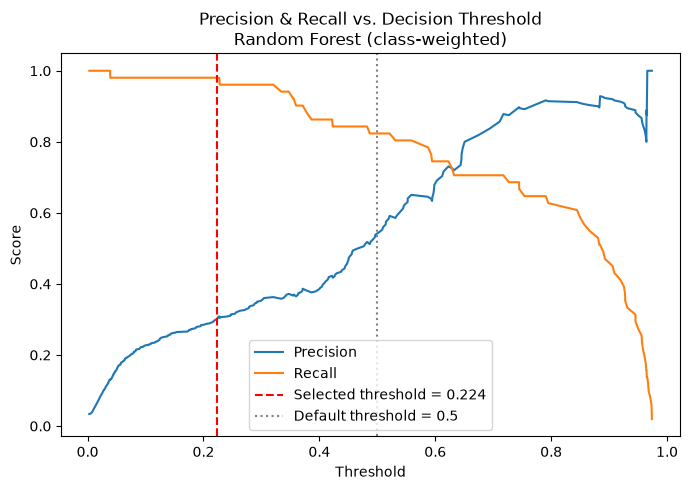

In [35]:
precisions, recalls, thresholds = precision_recall_curve(y_val, r_rf_weighted["y_proba"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, precisions[:-1], label="Precision")
ax.plot(thresholds, recalls[:-1], label="Recall")
ax.axvline(r_rf_tuned["threshold"], color="red", linestyle="--",
           label=f"Selected threshold = {r_rf_tuned['threshold']:.3f}")
ax.axvline(0.5, color="gray", linestyle=":", label="Default threshold = 0.5")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision & Recall vs. Decision Threshold\nRandom Forest (class-weighted)")
ax.legend()
plt.tight_layout()
plt.show()

**Observations of Random Forest — Threshold Optimization (weighted model)**

Lowering the decision threshold to 0.224 (from the default 0.5) pushes
recall to 98% — only **1 missed failure** out of 51 — compared to 9
missed failures at the default threshold on the same weighted model.
This comes at a steep precision cost: 30.3% precision, meaning 115 false
alarms versus 35 at the default threshold.

In [37]:
import pandas as pd
all_results = [r_logreg, r_dtree, r_rf, r_xgb, r_rf_weighted, r_rf_tuned]

comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("fitted_model", "y_val", "y_pred", "y_proba")}
    for r in all_results
])
comparison_df = comparison_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

comparison_df

,model,threshold,precision,recall,f1,pr_auc,false_negative_rate,tn,fp,fn,tp
0,Random Forest,0.500000,0.975000,0.764706,0.857143,0.904644,0.235294,1448,1,12,39
1,XGBoost,0.500000,0.854167,0.803922,0.828283,0.851770,0.196078,1442,7,10,41
2,Decision Tree (max_depth=5),0.500000,0.913043,0.823529,0.865979,0.832201,0.176471,1445,4,9,42
3,Random Forest (class-weighted),0.500000,0.545455,0.823529,0.656250,0.787485,0.176471,1414,35,9,42
4,Random Forest (weighted),0.223699,0.301205,0.980392,0.460829,0.787485,0.019608,1333,116,1,50
5,Logistic Regression — baseline,0.500000,0.550000,0.215686,0.309859,0.396428,0.784314,1440,9,40,11


## Hyperparameter Tuning
Random Forest (unweighted) is carried forward as our best model based on
PR-AUC (0.905) and precision (97.5%), per the project's stated priority
on ranking quality over raw accuracy. We tune it using
`RandomizedSearchCV` rather than a full grid search, since Random Forest
has several hyperparameters and an exhaustive grid would be expensive
relative to the marginal benefit — random search covers the space more
efficiently for this scope.

Given the small number of positive cases (339 total, ~237 in training),
we use **stratified k-fold cross-validation** (5 folds) on the training
set rather than a single validation split, to reduce variance in the
PR-AUC estimate used to select the best hyperparameters. Note we search
using the **training set only** — `X_val`/`y_val` are held out
completely from the search and used only afterward, to get an honest
final read on the tuned model.

In [93]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_distributions = {
    "n_estimators": [200, 300, 400, 500, 700],
    "max_depth": [4, 6, 8, 10, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=40,                     # number of random combinations to try
    scoring="average_precision",   # PR-AUC — matches our priority metric
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV PR-AUC:", rf_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 6}
Best CV PR-AUC: 0.90984920236446


In [94]:
r_rf_tuned_hp = train_and_evaluate(
    rf_search.best_estimator_,
    X_train, y_train, X_val, y_val,
    "Random Forest (hyperparameter-tuned)",
    already_fitted=True
)

=== Random Forest (hyperparameter-tuned) (threshold=0.500) ===
model: Random Forest (hyperparameter-tuned)
threshold: 0.5
precision: 0.9333333333333333
recall: 0.8235294117647058
f1: 0.875
pr_auc: 0.9307405369104367
false_negative_rate: 0.17647058823529413
tn: 1446
fp: 3
fn: 9
tp: 42

Full report:
               precision    recall  f1-score   support

           0      0.994     0.998     0.996      1449
           1      0.933     0.824     0.875        51

    accuracy                          0.992      1500
   macro avg      0.964     0.911     0.935      1500
weighted avg      0.992     0.992     0.992      1500



- Show here the best results of tunning

In [95]:
cv_results_df = pd.DataFrame(rf_search.cv_results_)
cv_results_df = cv_results_df.sort_values("mean_test_score", ascending=False)
cv_results_df[["params", "mean_test_score", "std_test_score"]].head(10)

,params,mean_test_score,std_test_score
2,"{'n_estimators': 400, 'min_samples_split': 2, ...",0.909849,0.035413
11,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.909277,0.036271
0,"{'n_estimators': 400, 'min_samples_split': 5, ...",0.909107,0.035643
14,"{'n_estimators': 700, 'min_samples_split': 2, ...",0.905903,0.037588
18,"{'n_estimators': 500, 'min_samples_split': 5, ...",0.904954,0.037351
37,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.901087,0.040675
19,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.899776,0.040599
30,"{'n_estimators': 400, 'min_samples_split': 10,...",0.899629,0.039205
4,"{'n_estimators': 500, 'min_samples_split': 10,...",0.899337,0.040236
32,"{'n_estimators': 300, 'min_samples_split': 10,...",0.898231,0.040707


## Saving All the work

In [96]:
all_results.append(r_rf_tuned_hp)

comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("fitted_model", "y_val", "y_pred", "y_proba")}
    for r in all_results
])
comparison_df = comparison_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)
comparison_df.to_csv("../reports/model_comparison_classical_ml.csv", index=False)
comparison_df

,model,threshold,precision,recall,f1,pr_auc,false_negative_rate,tn,fp,fn,tp
0,Random Forest (hyperparameter-tuned),0.500000,0.933333,0.823529,0.875000,0.930741,0.176471,1446,3,9,42
1,Random Forest,0.500000,0.975000,0.764706,0.857143,0.904644,0.235294,1448,1,12,39
2,XGBoost,0.500000,0.854167,0.803922,0.828283,0.851770,0.196078,1442,7,10,41
3,Decision Tree (max_depth=5),0.500000,0.913043,0.823529,0.865979,0.832201,0.176471,1445,4,9,42
4,Random Forest (class-weighted),0.500000,0.545455,0.823529,0.656250,0.787485,0.176471,1414,35,9,42
5,Random Forest (weighted),0.223699,0.303030,0.980392,0.462963,0.787485,0.019608,1334,115,1,50
6,Logistic Regression — baseline,0.500000,0.550000,0.215686,0.309859,0.396428,0.784314,1440,9,40,11


In [ ]:
import joblib

joblib.dump(rf_search.best_estimator_, "../models/random_forest_tuned_final.pkl")

final_model_metadata = {
    "model_name": "Random Forest (hyperparameter-tuned)",
    "best_params": rf_search.best_params_,
    "threshold": 0.5,
    "feature_names": feature_names,
    "val_metrics": {k: v for k, v in r_rf_tuned_hp.items()
                     if k not in ("fitted_model", "y_val", "y_pred", "y_proba")},
}

import json
with open("../reports/classical_ml_final_model_metadata.json", "w") as f:
    json.dump(final_model_metadata, f, indent=2, default=str)

print("Saved final model and metadata.")

Saved final model and metadata.


In [99]:
joblib.dump(preprocessor, "../models/preprocessor.pkl")
joblib.dump(zscorer, "../models/zscorer.pkl")

['../models/zscorer.pkl']